# 1. RIM-one mask (PNG) image check.
0(background), and 255(white mask).

In [1]:
import cv2

# This function runs every time your mouse does something
def click_event(event, x, y, flags, params):
    # If it's a left mouse click
    if event == cv2.EVENT_LBUTTONDOWN:
        # Grayscale images only have one intensity value, not B,G,R
        intensity = img[y, x]
        
        print(f"Coordinates (X:{x}, Y:{y}) - Pixel Value: [{intensity}]")
        
        # A quick visual helper
        if intensity == 255:
            print("  -> You clicked the WHITE region (The Mask)")
        elif intensity == 0:
            print("  -> You clicked the BLACK region (The Background)")
        else:
            print("  -> You clicked a gray edge pixel (Interpolated/Anti-aliased)")

# 1. Read the image explicitly in GRAYSCALE mode
img_path = 'data/1_rim_one/meshrcnn/GlaucomaDataset485SubjectsImages/segmentedRetinographies/normal/opticCup/opticCup000.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Could not load the image. Please check the path.")
else:
    # 2. Show the window
    cv2.imshow('RIM-ONE Mask Inspector', img)

    # 3. Attach the mouse clicker to the window
    cv2.setMouseCallback('RIM-ONE Mask Inspector', click_event)

    # 4. Wait for you to press any key to close
    print("Click anywhere on the image. Press any key on your keyboard to close the window.")
    cv2.waitKey(0)
    cv2.destroyAllWindows()

Click anywhere on the image. Press any key on your keyboard to close the window.


# 2-1. G1020 dataset mask check. --> 0,1,2 
We are going to convert this to rim-one dataset format - cup and disc masks

In [2]:
import cv2
import numpy as np

# Change this to the exact name of one of your masks
test_mask_path = "data/2_g1020_origa_refuge/G1020/Masks_Cropped/img/image_0.png" 
mask = cv2.imread(test_mask_path, cv2.IMREAD_GRAYSCALE)

print("Unique pixel values in this mask:", np.unique(mask))

Unique pixel values in this mask: [0 1 2]


In [5]:
import utils.utils
utils.utils.compare_crop_and_mask(img_path  = "data/2_g1020_origa_refuge/G1020/Images_Cropped/img/image_18.jpg",
                                  mask_path = "data/2_g1020_origa_refuge/G1020/Masks_Cropped/img/image_18.png")


[ WARN:0@142.993] global loadsave.cpp:241 findDecoder imread_('data/2_g1020_origa_refuge/G1020/Images_Cropped/img/image_18.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.10.0) /croot/opencv-suite_1752857031481/work/modules/imgproc/src/color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


# 2-2. Converting G1020 dataset masks to RIM-ONE format.

In [3]:
import os
import cv2
import numpy as np
import pandas as pd

# --- 1. CONFIGURATION ---
# CHANGE THIS: Set to 1 or 2 depending on which number was the inner Cup in your Plotly test
CUP_PIXEL_VALUE = 2 

# Paths
BASE_DIR     = "data/2_g1020_origa_refuge/G1020"
CSV_PATH     = os.path.join(BASE_DIR, "G1020.csv")
RAW_MASK_DIR = os.path.join(BASE_DIR, "Masks_Cropped/img")

# We will create a clean RIM-ONE style output folder here
OUTPUT_DIR = os.path.join(BASE_DIR, "segmentedRetinographies")

# --- 2. CREATE FOLDER STRUCTURE ---
folders_to_create = [
    "glaucoma/opticCup",
    "glaucoma/opticDisc",
    "normal/opticCup",
    "normal/opticDisc"
]

for folder in folders_to_create:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)
    
print("Created target directory structure.")

# --- 3. PROCESS THE DATASET ---
def build_dataset():
    df            = pd.read_csv(CSV_PATH)
    # print("df =", df)
    success_count = 0
    
    print(f"Processing {len(df)} images from CSV...")

    for index, row in df.iterrows():
        image_id = str(row['imageID'])
        label    = int(row['binaryLabels'])
        
        # Determine target folder based on label (0 = normal, 1 = glaucoma)
        class_folder = "glaucoma" if label == 1 else "normal"
        
        # The CSV has '.jpg' but the masks are actually '.png'.
        # We strip whatever extension the CSV has, and force it to look for .png
        base_filename = image_id.split('.')[0] # turns 'image_0.jpg' into 'image_0'
        raw_mask_path = os.path.join(RAW_MASK_DIR, f"{base_filename}.png")
        if not raw_mask_path.endswith(('.png', '.jpg')):
            raw_mask_path += ".png"
            
        if not os.path.exists(raw_mask_path):
            print(f"  [Skip] Could not find mask for {image_id}")
            continue
            
        # Read the raw mask containing 0, 1, 2
        raw_mask = cv2.imread(raw_mask_path, cv2.IMREAD_GRAYSCALE)
        
        if raw_mask is None:
            continue

        # --- EXTRACT BINARY MASKS (White = 255, Black = 0) ---
        # Cup is specifically the CUP_PIXEL_VALUE
        optic_cup = np.where(raw_mask == CUP_PIXEL_VALUE, 255, 0).astype(np.uint8)
        
        # Disc is the Cup + Rim, so it's any pixel greater than 0
        optic_disc = np.where(raw_mask > 0, 255, 0).astype(np.uint8)

        # --- SAVE THE NEW MASKS ---
        # Match RIM-ONE naming convention (e.g., opticCup_image_0.png)
        # We strip the extension from image_id first to prevent things like 'image_0.png.png'
        clean_id = image_id.split('.')[0] 
        
        cup_out_path = os.path.join(OUTPUT_DIR, class_folder, "opticCup", f"opticCup_{clean_id}.png")
        disc_out_path = os.path.join(OUTPUT_DIR, class_folder, "opticDisc", f"opticDisc_{clean_id}.png")
        
        cv2.imwrite(cup_out_path, optic_cup)
        cv2.imwrite(disc_out_path, optic_disc)
        
        success_count += 1

    print(f"\nDone! Successfully created {success_count} Cup/Disc pairs.")
    print(f"Saved to: {OUTPUT_DIR}")

if __name__ == "__main__":
    build_dataset()

Created target directory structure.
Processing 1020 images from CSV...

Done! Successfully created 1020 Cup/Disc pairs.
Saved to: data/2_g1020_origa_refuge/G1020/segmentedRetinographies


# 2-3. Matching file names.
We combined the train and test set of glaucoma and normal images together and applied CV.

This code verify how files are matched with file name in csv file.


In [4]:
import os
import cv2
import numpy as np

# --- 1. Define Paths ---
IMG_DIR  = "data/1_rim_one/RIM-ONE_DL_images/train_test_combined/glaucoma"
MASK_DIR = "data/1_rim_one/meshrcnn/GlaucomaDataset485SubjectsImages/segmentedRetinographies/glaucoma/opticCup"
OUT_DIR  = "data/1_rim_one/contour_check" # Changed folder name to reflect the new method

os.makedirs(OUT_DIR, exist_ok=True)

# --- 2. Load and Sort Files ---
valid_ext = ('.png', '.jpg', '.jpeg')
img_files = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith(valid_ext)])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.lower().endswith(valid_ext)])

num_pairs = min(len(img_files), len(mask_files))
print(f"Processing and saving {num_pairs} images to '{OUT_DIR}'...")

# --- 3. Process and Draw Exact Outlines ---
for i in range(num_pairs):
    img_name = img_files[i]
    mask_name = mask_files[i]
    
    img_path = os.path.join(IMG_DIR, img_name)
    mask_path = os.path.join(MASK_DIR, mask_name)
    
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None or mask is None:
        continue
        
    if img.shape[:2] != mask.shape:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        
    # Ensure mask is strictly binary (0 or 255)
    _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    
    # Find the exact outline(s) of the white mask area
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        # Draw the exact curved outline in Cyan/Yellow
        # Parameters: image, contours, contourIdx (-1 means all), color(B,G,R), thickness
        cv2.drawContours(img, contours, -1, (0, 255, 255), 2)
        
        # Put the label near the top of the largest contour
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour) # Only used to place the text
        cv2.putText(img, 'Optic Cup', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    else:
        print(f"Warning: Mask {mask_name} is completely empty/black.")
        
    out_path = os.path.join(OUT_DIR, f"contour_{img_name}")
    cv2.imwrite(out_path, img)

print("Done! Check the 'contour_check' folder to see the exact shapes.")

Processing and saving 172 images to 'data/1_rim_one/contour_check'...
Done! Check the 'contour_check' folder to see the exact shapes.


# 3. ORIGA dataset
mask check --> 0,1,2

In [ ]:
import utils.utils
utils.utils.mask_inspection(test_mask_path = "data/2_g1020_origa_refuge/ORIGA/Masks_Cropped/001.png" )

/home/holidayj/anaconda3/envs/hj/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unique pixel values in this mask: [0 1 2]


In [3]:
import utils.utils
utils.utils.compare_crop_and_mask(img_path  = "data/2_g1020_origa_refuge/ORIGA/Images_Cropped/001.jpg",
                                  mask_path = "data/2_g1020_origa_refuge/ORIGA/Masks_Cropped/001.png")

# converting mask to rim-one dataset format

In [1]:
import os
import cv2
import numpy as np
import pandas as pd

# --- 1. CONFIGURATION ---
# CHANGE THIS: Set to 1 or 2 depending on which number was the inner Cup in your Plotly test
CUP_PIXEL_VALUE = 2 

# Paths
BASE_DIR     = "data/2_g1020_origa_refuge/ORIGA"
# Make sure to change this to your actual ORIGA CSV filename if it's different!
CSV_PATH     = os.path.join(BASE_DIR, "origa_info.csv") 
RAW_MASK_DIR = os.path.join(BASE_DIR, "Masks_Cropped")

# We will create a clean RIM-ONE style output folder here
OUTPUT_DIR = os.path.join(BASE_DIR, "segmentedRetinographies")

# --- 2. CREATE FOLDER STRUCTURE ---
folders_to_create = [
    "glaucoma/opticCup",
    "glaucoma/opticDisc",
    "normal/opticCup",
    "normal/opticDisc"
]

for folder in folders_to_create:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)
    
print("Created target directory structure.")

# --- 3. PROCESS THE DATASET ---
def build_dataset():
    df            = pd.read_csv(CSV_PATH)
    success_count = 0
    
    print(f"Processing {len(df)} images from CSV...")

    for index, row in df.iterrows():
        # 1. Extract the full path from the 'Image' column
        full_image_path = str(row['Image'])
        
        # 2. Extract just the filename (e.g., "001.jpg" from "/content/.../001.jpg")
        image_id = os.path.basename(full_image_path)
        
        # 3. Extract the label from the 'Label' column
        label = int(row['Label'])
        
        # Determine target folder based on label (0 = normal, 1 = glaucoma)
        class_folder = "glaucoma" if label == 1 else "normal"
        
        # Strip the extension to get just the base name (e.g., '001')
        base_filename = image_id.split('.')[0] 
        
        # Build the path to the corresponding mask
        raw_mask_path = os.path.join(RAW_MASK_DIR, f"{base_filename}.png")
            
        if not os.path.exists(raw_mask_path):
            print(f"  [Skip] Could not find mask for {image_id}")
            continue
            
        # Read the raw mask containing 0, 1, 2
        raw_mask = cv2.imread(raw_mask_path, cv2.IMREAD_GRAYSCALE)
        
        if raw_mask is None:
            print(f"  [Error] Failed to read mask file: {raw_mask_path}")
            continue

        # --- EXTRACT BINARY MASKS (White = 255, Black = 0) ---
        # Cup is specifically the CUP_PIXEL_VALUE
        optic_cup = np.where(raw_mask == CUP_PIXEL_VALUE, 255, 0).astype(np.uint8)
        
        # Disc is the Cup + Rim, so it's any pixel greater than 0
        optic_disc = np.where(raw_mask > 0, 255, 0).astype(np.uint8)

        # --- SAVE THE NEW MASKS ---
        # Match RIM-ONE naming convention (e.g., opticCup_001.png)
        cup_out_path  = os.path.join(OUTPUT_DIR, class_folder, "opticCup", f"opticCup_{base_filename}.png")
        disc_out_path = os.path.join(OUTPUT_DIR, class_folder, "opticDisc", f"opticDisc_{base_filename}.png")
        
        cv2.imwrite(cup_out_path, optic_cup)
        cv2.imwrite(disc_out_path, optic_disc)
        
        success_count += 1

    print(f"\nDone! Successfully created {success_count} Cup/Disc pairs.")
    print(f"Saved to: {OUTPUT_DIR}")

if __name__ == "__main__":
    build_dataset()

Created target directory structure.
Processing 650 images from CSV...

Done! Successfully created 650 Cup/Disc pairs.
Saved to: data/2_g1020_origa_refuge/ORIGA/segmentedRetinographies


Calculating CDR andRDR.

In [ ]:
import os
import cv2
import numpy as np
import csv
import math
import pandas as pd

# ==========================================
# 1. RDR Helper Functions
# ==========================================
def get_centroid(binary_img):
    coords = np.column_stack(np.where(binary_img > 0)) 
    if len(coords) == 0:
        return None
    cy, cx = np.mean(coords, axis=0)
    return (cx, cy)

def find_boundary_along_line(binary_img, start, direction, step=0.5, max_steps=2000):
    h, w = binary_img.shape[:2]
    length = math.hypot(direction[0], direction[1])
    if length < 1e-12:
        return start
    
    dx = direction[0] / length
    dy = direction[1] / length
    
    x, y = start
    boundary_x, boundary_y = x, y
    
    for _ in range(max_steps):
        x_next = x + dx * step
        y_next = y + dy * step
        
        ix_next = int(round(x_next))
        iy_next = int(round(y_next))
        
        if ix_next < 0 or ix_next >= w or iy_next < 0 or iy_next >= h:
            break
        
        if binary_img[iy_next, ix_next] > 0: 
            x, y = x_next, y_next
            boundary_x, boundary_y = x, y
        else:
            break
    
    return (boundary_x, boundary_y)

# ==========================================
# 2. Main Metric Calculation Functions
# ==========================================
def calculate_cdr(optic_cup, optic_disc, log_file, dataset_type, image_index):
    y_oc = np.where(optic_cup > 0)[0]
    y_od = np.where(optic_disc > 0)[0]

    log_file.write(f"{dataset_type}, opticCup,  {image_index}, {y_oc.tolist()}\n")
    log_file.write(f"{dataset_type}, opticDisc, {image_index}, {y_od.tolist()}\n")

    if len(y_od) == 0:
        raise ValueError("Optic disc edges are not detected (mask is completely black).")
    if len(y_oc) == 0:
        return 0.0  # Healthy eye with no visible cup

    oc_vd = y_oc.max() - y_oc.min()
    od_vd = y_od.max() - y_od.min()

    if od_vd == 0:
        raise ValueError("Optic disc vertical diameter is zero.")

    return oc_vd / od_vd

def compute_rdr(disc_img, cup_img, n_directions=12):
    disc_center = get_centroid(disc_img)
    cup_center  = get_centroid(cup_img)
    
    if disc_center is None:
        return None  
    if cup_center is None:
        return 1.0   
    
    possible_rdr_values = []
    angle_step = 360.0 / n_directions
    
    for i in range(n_directions):
        theta = math.radians(i * angle_step)
        dx = math.cos(theta)
        dy = math.sin(theta)
        
        Q = find_boundary_along_line(disc_img, disc_center, (dx, dy))
        disc_radius = math.dist(disc_center, Q)
        
        P = find_boundary_along_line(cup_img, disc_center, (dx, dy))
        rim_thickness = math.dist(P, Q)
        
        if disc_radius > 1e-6:
            ratio = rim_thickness / disc_radius
            possible_rdr_values.append(ratio)
    
    if not possible_rdr_values:
        return None

    return min(possible_rdr_values)

# ==========================================
# 3. Processing Core
# ==========================================
def find_mask(mask_base_folder, category, orig_basename, part_name, index):
    """Dynamically searches multiple possible paths for the mask file."""
    possible_paths = [
        # 1. EXACT MATCH for G1020 & ORIGA (Category folder + Prefix)
        # e.g., .../glaucoma/opticCup/opticCup_image_1000.png
        os.path.join(mask_base_folder, category, part_name, f"{part_name}_{orig_basename}.png"),
        
        # 2. RIM-ONE Style (Category folder + Indexed)
        # e.g., .../glaucoma/opticCup/opticCup000.png
        os.path.join(mask_base_folder, category, part_name, f"{part_name}{index:03d}.png"),
        
        # 3. Category folder, no prefix
        # e.g., .../glaucoma/opticCup/image_1000.png
        os.path.join(mask_base_folder, category, part_name, f"{orig_basename}.png"),
        
        # 4. Flat folder, with prefix
        # e.g., .../opticCup/opticCup_image_1000.png
        os.path.join(mask_base_folder, part_name, f"{part_name}_{orig_basename}.png"),
        
        # 5. Flat folder, no prefix
        # e.g., .../opticCup/image_1000.png
        os.path.join(mask_base_folder, part_name, f"{orig_basename}.png"),
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            return path
    return None

def process_single_dataset(dataset_name, mask_base_folder, orig_base_folder, output_csv, csv_labels_path=None):
    print(f"\n{'='*50}")
    print(f"🚀 STARTING DATASET: {dataset_name}")
    print(f"{'='*50}")
    
    os.makedirs(os.path.dirname(output_csv), exist_ok=True) 

    glaucoma_orig_files = []
    normal_orig_files = []

    # Read Labels directly from CSV if provided
    if csv_labels_path and os.path.exists(csv_labels_path):
        print(f"Reading labels from CSV: {csv_labels_path}")
        df = pd.read_csv(csv_labels_path)
        
        # Dynamically find the correct column names for image and label
        img_col = 'Image' if 'Image' in df.columns else ('imageID' if 'imageID' in df.columns else df.columns[0])
        lbl_col = 'Label' if 'Label' in df.columns else ('binaryLabels' if 'binaryLabels' in df.columns else df.columns[1])

        # Ensure image paths in the CSV are stripped down to just the filenames (fixes ORIGA's long paths)
        df[img_col] = df[img_col].apply(lambda x: os.path.basename(str(x)))

        glaucoma_orig_files = df[df[lbl_col] == 1][img_col].tolist()
        normal_orig_files = df[df[lbl_col] == 0][img_col].tolist()

        glaucoma_orig_files.sort()
        normal_orig_files.sort()
        
    # Fallback to reading Subfolders
    else:
        glauc_dir = os.path.join(orig_base_folder, "glaucoma")
        norm_dir  = os.path.join(orig_base_folder, "normal")
        valid_ext = ('.png', '.jpg', '.jpeg')
        
        glaucoma_orig_files = sorted([f for f in os.listdir(glauc_dir) if f.lower().endswith(valid_ext)]) if os.path.exists(glauc_dir) else []
        normal_orig_files   = sorted([f for f in os.listdir(norm_dir) if f.lower().endswith(valid_ext)]) if os.path.exists(norm_dir) else []

    # Setup files for writing
    log_path = output_csv.replace(".csv", "_log.txt")
    with open(log_path, "w") as log_file, open(output_csv, mode='w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow(["Dataset", "Image Index", "Original Image Name", "CDR", "RDR"])

        def process_category(category, orig_files_list):
            num_images = len(orig_files_list)
            if num_images == 0:
                print(f"  [Skip] No images found for {category.capitalize()}")
                return
                
            print(f"Processing {category.capitalize()} images... (Auto-detected {num_images} images)")

            for i in range(num_images):
                orig_name = orig_files_list[i]
                orig_basename = os.path.splitext(orig_name)[0]
                
                # Use smart finder to locate masks
                cup_path = find_mask(mask_base_folder, category, orig_basename, "opticCup", i)
                disc_path = find_mask(mask_base_folder, category, orig_basename, "opticDisc", i)

                # PREVENT OPENCV CRASH: Ensure files exist before reading
                if not cup_path or not disc_path:
                    print(f"  [Warning] Missing masks for '{orig_name}'. Skipping.")
                    csv_writer.writerow([category, i, orig_name, "Error: Missing Mask", "Error: Missing Mask"])
                    continue

                # Load images
                optic_cup  = cv2.imread(cup_path, cv2.IMREAD_GRAYSCALE)
                optic_disc = cv2.imread(disc_path, cv2.IMREAD_GRAYSCALE)

                # Calculate CDR
                try:
                    cdr_val = calculate_cdr(optic_cup, optic_disc, log_file, category, orig_name)
                    cdr_str = f"{cdr_val:.4f}" if isinstance(cdr_val, float) else cdr_val
                except ValueError as e:
                    cdr_str = f"Error: {str(e)}"

                # Calculate RDR
                rdr_val = compute_rdr(optic_disc, optic_cup, n_directions=12)
                rdr_str = "NaN" if rdr_val is None else f"{rdr_val:.4f}"

                csv_writer.writerow([category, i, orig_name, cdr_str, rdr_str])

        process_category("glaucoma", glaucoma_orig_files)
        process_category("normal", normal_orig_files)

    print(f"✅ Process complete! {dataset_name} data saved to: {output_csv}")

# ==========================================
# 4. Main Configuration & Execution
# ==========================================
if __name__ == "__main__":
    
    DATASETS = [
        # {
        #     "name": "RIM-ONE",
        #     "mask_base": "data/1_rim_one/meshrcnn/GlaucomaDataset485SubjectsImages/segmentedRetinographies",
        #     "orig_base": "data/1_rim_one/RIM-ONE_DL_images/train_test_combined",
        #     "output_csv": "data/final_combined_results_rim_one.csv",
        #     "csv_labels": None  
        # },
        # {
        #     "name": "G1020",
        #     "mask_base": "data/2_g1020_origa_refuge/G1020/segmentedRetinographies",
        #     "orig_base": "data/2_g1020_origa_refuge/G1020/Images", 
        #     "output_csv": "data/final_combined_results_g1020.csv",
        #     "csv_labels": "data/2_g1020_origa_refuge/G1020/G1020.csv" 
        # },
        {
            "name": "ORIGA",
            "mask_base": "data/2_g1020_origa_refuge/ORIGA/segmentedRetinographies",
            "orig_base": "data/2_g1020_origa_refuge/ORIGA/Images", 
            "output_csv": "data/final_combined_results_origa.csv",
            "csv_labels": "data/2_g1020_origa_refuge/ORIGA/origa_info.csv" # Ensure this matches your actual CSV filename
        }
    ]

    for config in DATASETS:
        process_single_dataset(
            dataset_name     = config["name"],
            mask_base_folder = config["mask_base"],
            orig_base_folder = config["orig_base"],
            output_csv       = config["output_csv"],
            csv_labels_path  = config["csv_labels"]
        )


🚀 STARTING DATASET: ORIGA
Reading labels from CSV: data/2_g1020_origa_refuge/ORIGA/origa_info.csv
Processing Glaucoma images... (Auto-detected 168 images)
Processing Normal images... (Auto-detected 482 images)
✅ Process complete! ORIGA data saved to: data/final_combined_results_origa.csv


# PapilaDB dataset

In [3]:
# final csv creation for papilaDB.
!python utils/papila_csv_creator.py

🚀 Starting PapilaDB Clinical Feature Extraction...
Processing 155 images in 'glaucoma'...
Processing 333 images in 'normal'...

✅ Successfully saved 488 records to data/final_combined_results_papila.csv


# REFUGE dataset

In [4]:
import utils.utils
utils.utils.mask_inspection(test_mask_path = "data/2_g1020_origa_refuge/REFUGE/val/Masks_Cropped/V0001.png")

Unique pixel values in this mask: [0 1 2]


In [ ]:
import utils.utils
utils.utils.compare_crop_and_mask(img_path  = "data/2_g1020_origa_refuge/REFUGE/val/Images_Cropped/V0001.jpg", 
                                  mask_path = "data/2_g1020_origa_refuge/REFUGE/val/Masks_Cropped/V0001.png")

/home/holidayj/anaconda3/envs/hj/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
!python utils/refuge_csv_creator.py

🚀 INITIALIZING UNIFIED REFUGE PROCESSING
📂 Target Images: data/2_g1020_origa_refuge/REFUGE/cropped_images_train_val
📂 Target Masks: data/2_g1020_origa_refuge/REFUGE/segmentedRetinographies

Processing 'train' split: 400 images found.

Processing 'val' split: 400 images found.

✅ Done! Unified 800 total images and masks from Train & Val.
✅ Images saved to: data/2_g1020_origa_refuge/REFUGE/cropped_images_train_val
✅ Masks saved to: data/2_g1020_origa_refuge/REFUGE/segmentedRetinographies
✅ Unified CSV saved to: data/final_combined_results_refuge.csv



=== Verifying Unified REFUGE Dataset ===
✅ Found 800 records in CSV. Drawing 3 random samples...



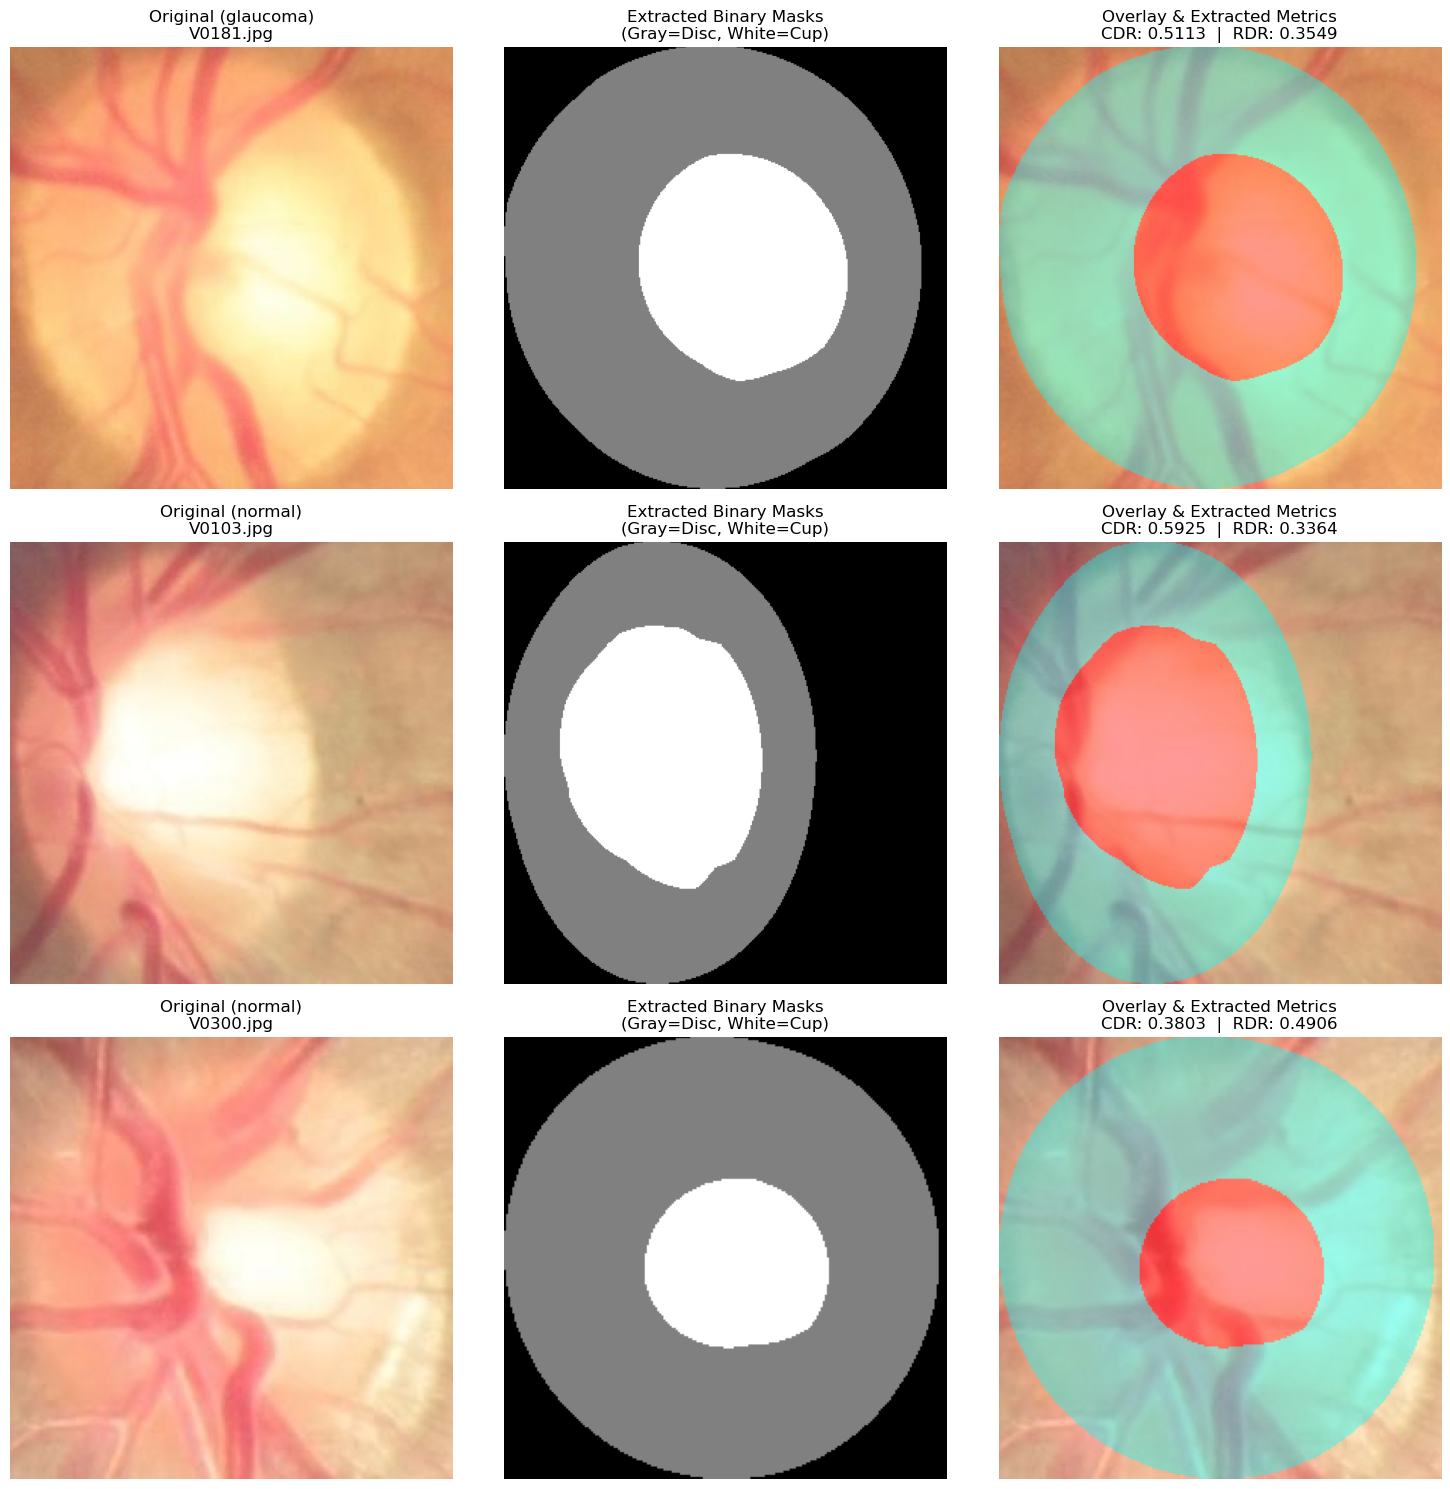

In [3]:
import utils.refuge_csv_creator
utils.refuge_csv_creator.verify_refuge_extraction(num_samples=3)

## Train REFUGE dataset.